In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import numpy as np
import json
import corner
from snr_average import average_snr

label_fontsize = 18
tick_fontsize = 18
title_fontsize = 18

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams["figure.figsize"] = (4, 3)


In [40]:
m1_list = np.logspace(4, 7, 30)
z_list = np.logspace(-2, 0.5, 30)
m2 = 10.0
a = 0.99
ef = 0.0
Tobs = 1.0
psd = "LISA"
num_freq = 5000
num_samples = 1 # averaging

In [41]:
from multiprocessing import get_context, cpu_count

# Toggle
use_parallel = True
n_proc = max(1, cpu_count() - 1)

def _snr_task(args):
    i, j, m1, z = args
    snrs, _ = average_snr(
        m1,
        m2,
        a,
        Tobs,
        ef,
        z,
        psd=psd,
        num_freq=num_freq,
        num_samples=num_samples,
        seed=2601 + i * 1000 + j,  # per-task seed
        pool=None,
    )
    return i, j, float(np.mean(snrs))

snr_waterfall = np.zeros((len(m1_list), len(z_list)))
tasks = [(i, j, m1, z) for i, m1 in enumerate(m1_list) for j, z in enumerate(z_list)]

if use_parallel:
    # "fork" works well in many Unix/Jupyter setups; fallback to "spawn"
    try:
        ctx = get_context("fork")
    except ValueError:
        ctx = get_context("spawn")

    with ctx.Pool(processes=n_proc) as pool:
        for i, j, snr_val in pool.imap_unordered(_snr_task, tasks):
            snr_waterfall[i, j] = snr_val
else:
    for t in tasks:
        i, j, snr_val = _snr_task(t)
        snr_waterfall[i, j] = snr_val


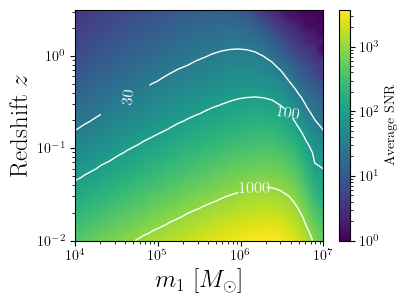

In [81]:
from matplotlib.colors import LogNorm

cb = plt.pcolormesh(
    m1_list,
    z_list,
    snr_waterfall.T,
    shading='gouraud',
    cmap='viridis',
    norm=LogNorm(vmin=1.0, vmax=np.nanmax(snr_waterfall))
)

clab = plt.contour(
    m1_list,
    z_list,
    snr_waterfall.T,
    levels=[30, 100, 1000],
    colors='white',
    linewidths=1.0,
    linestyles='solid'
)

plt.clabel(clab, fmt='%1.0f', colors='white', fontsize=label_fontsize/1.5, inline=True, inline_spacing=1)
plt.xlabel(r"$m_1$ [$M_\odot$]", fontsize=label_fontsize)
plt.ylabel(r"Redshift $z$", fontsize=label_fontsize)
plt.xscale('log')
plt.yscale('log')
plt.colorbar(cb, label=r"Average SNR")
plt.xlim(m1_list[0], m1_list[-1])
plt.ylim(z_list[0], z_list[-1])
plt.show()
